In [1]:
import os
import cryo
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Retrieve the Ethereum RPC URL from environment variables
eth_rpc = os.getenv("ETH_RPC")

ModuleNotFoundError: No module named 'cryo'

### 1 detailed listing of data for the specified range of Ethereum blocks.

In [2]:
# Collect blockchain data using the cryo library and return it as a pandas DataFrame
# Specifying blocks range and output format
data = cryo.collect(
    "blocks", 
    blocks=["18734050:18735050"], 
    rpc=eth_rpc, 
    output_format="pandas", 
    hex=True
)

# Displaying the column names of the DataFrame
print("Columns in the DataFrame:")
for column in data.columns:
    print(column)

# Print the entire DataFrame
print(data)

Columns in the DataFrame:
block_hash
author
block_number
gas_used
extra_data
timestamp
base_fee_per_gas
chain_id
                                            block_hash  \
0    0xdf6d5d7526eb50e68278998b2cc7a519a4c3daddb14a...   
1    0x2818389bb471ebe60a74fb1865574c0ac50f40daf575...   
2    0xd65229e3d67c28f71b978ae789df6ee58c27420f8a35...   
3    0x218f26e524d889d20604ad01b91feec5c2285dc3e747...   
4    0xace296b1c263fee4f35d831086c93aa820577dcc1bea...   
..                                                 ...   
995  0xc59d9ad3444b0352c36f3ec7e3a3561bbc90d9118232...   
996  0xd611033a7769913ba0e8abdc8ae0ab0fee224435c512...   
997  0x2a4448fe72e37c169868e37ea4fce71789c31ecc9108...   
998  0x6ce066a304e334c6a98154b51f2a1b24edf749467424...   
999  0xbc293dc0e8d0a61f24256433f7faaf2a8e754a5557d9...   

                                         author  block_number  gas_used  \
0    0xcdbf58a9a9b54a2c43800c50c7192946de858321      18734050  18808397   
1    0xdafea492d9c6733ae3d56b7ed1adb6069

### 2 Fetching ERC-20 balances with cryo

In [5]:
import os
from dotenv import load_dotenv
import cryo

# Load environment variables
load_dotenv()

# Access Ethereum RPC URL from environment variables
eth_rpc = os.getenv("ETH_RPC")

# Fetch ERC-20 token balances for a specified address within a block range
data = cryo.freeze(
    "erc20_balances",
    blocks=["18.68M:18.69M"],
    contract=['0x4d224452801ACEd8B2F0aebE155379bb5D594381'],
    address=['0xF977814e90dA44bFA03b6295A0616a897441aceC'],
    rpc=eth_rpc,
    output_dir="blocks_data/",
    file_format="json",
    hex=True,
    requests_per_second=900
)


### 3 vizu

In [ ]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from web3 import Web3
import cryo

# Constants
ETH_RPC_VAR = "ETH_RPC"
LOOKBACK_BLOCKS = 5000
TOP_AUTHORS_COUNT = 10

# Load environment variables
load_dotenv()

# Function to get the block range
def get_block_range(web3, lookback_blocks):
    latest_block = web3.eth.block_number
    start_block = max(0, latest_block - lookback_blocks)  # Avoid negative block numbers
    return f"{start_block}:{latest_block}"

# Function to fetch data from cryo
def fetch_block_data(block_range, eth_rpc):
    try:
        # Start timer for fetching blocks
        fetch_start_time = time.time()

        # Fetch the block data
        data = cryo.collect(
            "blocks", blocks=[block_range], rpc=eth_rpc, output_format="pandas", hex=True
        )

        # Calculate and print the time taken to fetch the blocks
        fetch_time = time.time() - fetch_start_time
        print(f"Time taken to fetch blocks: {fetch_time:.2f} seconds")
        return data
    except Exception as e:
        print(f"An error occurred while fetching block data: {e}")
        return pd.DataFrame()  # Return an empty DataFrame on error

# Function to plot the top authors
def plot_top_authors(data, num_entries):
    top_authors = data['author'].value_counts().head(TOP_AUTHORS_COUNT)
    plt.figure(figsize=(12, 6))
    top_authors.plot(kind='bar')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {TOP_AUTHORS_COUNT} Authors by number of blocks mined from past {num_entries} blocks', fontsize=14)
    plt.xlabel('Author', fontsize=14)
    plt.ylabel('Number of Blocks', fontsize=14)
    plt.tight_layout()
    plt.show()

# Main execution
def main():
    eth_rpc = os.getenv(ETH_RPC_VAR)
    if not eth_rpc:
        raise ValueError(f"Environment variable {ETH_RPC_VAR} not found")

    w3 = Web3(Web3.HTTPProvider(eth_rpc))
    if not w3.is_connected():
        print("Failed to connect to Ethereum node.")
        return

    block_range = get_block_range(w3, LOOKBACK_BLOCKS)
    print(f"Fetching blocks from {block_range} range.")
    
    data = fetch_block_data(block_range, eth_rpc)
    if not data.empty:
        num_entries = len(data)
        print(f"Number of blocks fetched: {num_entries}")
        plot_top_authors(data, num_entries)

if __name__ == "__main__":
    main()

### TOKEN BALANCE CHANGE

Data fetched in 32.28 seconds.

Data summary:
Block rage: 20971444:20978644
Start balance in Ether: 25036.35764767035248691
End balance in Ether: 25309.749693292994766242


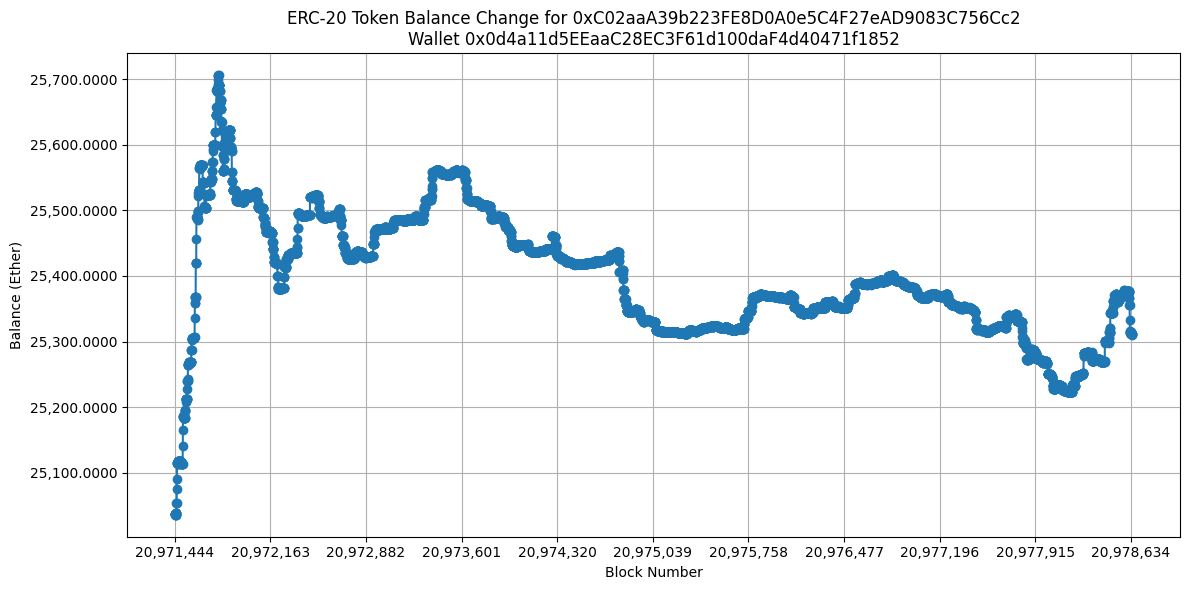

In [9]:
import os
import time
from dotenv import load_dotenv
import cryo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from web3 import Web3

# Constants
ETH_RPC_VAR = "ETH_RPC"
LOOKBACK_BLOCKS = 7200 # Approx a day in the past
CONTRACT_ADDRESS = '0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2' # WETH
WALLET_ADDRESS = '0x0d4a11d5EEaaC28EC3F61d100daF4d40471f1852'   # WETH-USDT pool Uniswap V2

# Initialize environment variables and Web3
load_dotenv()
eth_rpc = os.getenv(ETH_RPC_VAR)
w3 = Web3(Web3.HTTPProvider(eth_rpc))

def check_eth_rpc_connection(eth_rpc):
    """Check connection to Ethereum RPC."""
    if not eth_rpc:
        raise ValueError(f"Environment variable {ETH_RPC_VAR} not found")
    if not w3.is_connected():
        raise ConnectionError("Failed to connect to Ethereum node.")

def get_block_range(lookback_blocks):
    """Determine the range of blocks to fetch."""
    latest_block = w3.eth.block_number
    start_block = max(0, latest_block - lookback_blocks)
    return f"{start_block}:{latest_block}"

def fetch_erc20_balances(block_range):
    """Fetch ERC-20 token balances within a given block range."""
    return cryo.collect(
        "erc20_balances",
        blocks=[block_range],
        contract=[CONTRACT_ADDRESS],
        address=[WALLET_ADDRESS],
        rpc=eth_rpc,
        output_format="pandas",
        hex=True,
        requests_per_second=900 # Adapt the RPS to your endpoint
    )

def convert_balance_to_ether(balance_str):
    """Convert balance from Wei to Ether, handling None values."""
    return None if balance_str is None else Web3.from_wei(int(balance_str), 'ether')

def plot_balance_change_over_time(data):
    """Plot the balance change over time on a chart."""
    plt.figure(figsize=(12, 6))
    plt.plot(data['block_number'], data['balance_ether'], marker='o')

    # Set axis labels and chart title with contract and address
    plt.xlabel("Block Number")
    plt.ylabel("Balance (Ether)")
    plt.title(f"ERC-20 Token Balance Change for {CONTRACT_ADDRESS}\nWallet {WALLET_ADDRESS}")

    # Manually set the x-axis ticks based on the block range
    block_numbers = data['block_number']
    tick_spacing = (block_numbers.max() - block_numbers.min()) // 10  # for example, 10 evenly spaced ticks
    ticks = range(int(block_numbers.min()), int(block_numbers.max()), int(tick_spacing))
    plt.xticks(ticks, [f"{tick:,.0f}" for tick in ticks])

    # Format the y-axis to show balances rounded to 4 decimal places
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

    # Add grid, tighten layout, and display the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    """Main function to fetch and plot ERC-20 token balance changes."""
    check_eth_rpc_connection(eth_rpc)
    block_range = get_block_range(LOOKBACK_BLOCKS)

    # Start timing the data fetch
    start_time = time.time()

    # Fetch the data
    data = fetch_erc20_balances(block_range)

    # End timing the data fetch
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Data fetched in {elapsed_time:.2f} seconds.")

    if data.empty:
        print("No data available for plotting.")
        return
    
    # Prepare data for plotting
    data = data[['block_number', 'erc20', 'address', 'balance_string']]
    data['balance_ether'] = data['balance_string'].apply(convert_balance_to_ether)
    data = data[data['balance_ether'].notnull()]  # Filter out rows with None values

    # Print data summary to the console
    print("\nData summary:")
    print(f"Block rage: {block_range}")
    print(f"Start balance in Ether: {data.iloc[0]['balance_ether']}")
    print(f"End balance in Ether: {data.iloc[-1]['balance_ether']}")

    # Plot the balance changes over time
    plot_balance_change_over_time(data)

if __name__ == "__main__":
    main()

In [8]:
erc20_tokens = [
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48",  # USDC
    "0xdac17f958d2ee523a2206206994597c13d831ec7"   # USDT
]

wallets = [
    "0x0a59649758aa4d66e25f08dd01271e891fe52199",  # Maker PSM
    "0xcee284f754e854890e311e3280b767f80797180d"   # Arbitrum Bridge
]

block_range = "16M:17M/10"  # 10 blocks between 16,000,000 and 17,000,000

# Fetch the ERC20 balances data
data = cryo.collect(
    "erc20_balances", 
    blocks=block_range, 
    contract=erc20_addresses, 
    address=wallet_addresses, 
    rpc=eth_rpc, 
    output_format="pandas")


An error occurred while fetching ERC20 balances: argument 'blocks': Can't extract `str` to `Vec`
Empty DataFrame
Columns: []
Index: []
